# LULC Classification: Uncertainty Quantification Pipeline
**Project:** Multispectral Image Analysis & Uncertainty Quantification  
**Author:** Danesh Selwal  
**Date:** 2026-05-02

---
## Executive Summary
This notebook evaluates post-hoc uncertainty over pretrained LULC classifiers and exports quantitative and spatial outputs for analysis.

**Objective:**
Apply uncertainty estimation methods, compare model behavior, and export reproducible artifacts to esults/ for reporting.

---
## 1. Environment Setup & Configuration
Import dependencies, configure runtime paths, and initialize reproducibility settings before running evaluation.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import sys

MODULE_NAME = 'dapm'
REPO_ROOT = Path("/content/drive/MyDrive/Dias_Uncertainty_Quantification")
MODULE_DIR = REPO_ROOT / MODULE_NAME
RESULTS_DIR = MODULE_DIR / 'results'
MODELS_DIR = MODULE_DIR / 'models'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Module: {MODULE_NAME}')
print(f'Output Directory: {RESULTS_DIR}')


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow C++ INFO/WARNING logs
import os
import sys
import io
import gc
import json
import random
import warnings
import subprocess                          # ← ADD
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from scipy.stats import ttest_ind
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch        # ← ADD

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)





Mounted at /content/drive


In [3]:
# -----------------------------
# Configuration
# -----------------------------
PROJECT_ROOT = REPO_ROOT

DATA_DIR = REPO_ROOT / "data"
MODEL_DIR = MODELS_DIR
DAPM_DIR = MODELS_DIR
OUTPUT_DIR = RESULTS_DIR / 'dapm_full'
CHUNK_DIR = OUTPUT_DIR / 'chunk_outputs'
MAP_DIR = RESULTS_DIR / "maps"
CHUNK_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / "DIAS.mat"
LABEL_FILE = DATA_DIR / "DIAS_ref.mat"

MODEL_KEYS = ['AlexNet_CNN', 'GFNet', 'ViT_UNet']
MODEL_FILES = {
    'AlexNet_CNN': MODEL_DIR / 'AlexNet_CNN_best.keras',
    'GFNet': MODEL_DIR / 'GFNet_best.keras',
    'ViT_UNet': MODEL_DIR / 'ViT_UNet_best.keras',
}

H, W, B = 330, 307, 6
PATCH_SIZE = 9
N_SAMPLES = 30
BATCH_SIZE = 128
SCENE_CHUNK_SIZE = 1000
P_THRESH = 0.05

EXCEL_PATH = OUTPUT_DIR / 'dapm_full_reports_all_models.xlsx'
SUMMARY_CSV_PATH = OUTPUT_DIR / 'dapm_full_summary_metrics.csv'
RUN_CONFIG_JSON_PATH = OUTPUT_DIR / 'dapm_full_run_config.json'

MODEL_NAME_MAP = {
    'AlexNet_CNN': 'AlexNet',
    'GFNet': 'GFNet',
    'ViT_UNet': 'ViT',
}
PER_CLASS_CSV_PATH = OUTPUT_DIR / 'dapm_full_per_class_metrics.csv'



In [4]:
# -----------------------------
# Copy all needed files to local /content to avoid Drive FUSE errors
# -----------------------------
import shutil

LOCAL_MODEL_DIR = MODELS_DIR
LOCAL_DAPM_DIR = MODELS_DIR
LOCAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_DAPM_DIR.mkdir(parents=True, exist_ok=True)

# Copy base .keras models
LOCAL_MODEL_FILES = {}
for mk, src_path in MODEL_FILES.items():
    dst_path = LOCAL_MODEL_DIR / src_path.name
    if not dst_path.exists():
        print(f'Copying {src_path.name} to local ...')
        shutil.copy2(str(src_path), str(dst_path))
    LOCAL_MODEL_FILES[mk] = dst_path
    print(f'  {mk}: {dst_path}  ({dst_path.stat().st_size / 1e6:.1f} MB)')

# Copy DAPM artifact files (configs + weights)
for f in DAPM_DIR.iterdir():
    dst = LOCAL_DAPM_DIR / f.name
    if not dst.exists():
        shutil.copy2(str(f), str(dst))
LOCAL_DAPM_DIR_ORIG = DAPM_DIR          # keep reference
DAPM_DIR = LOCAL_DAPM_DIR               # redirect all reads to local
MODEL_FILES = LOCAL_MODEL_FILES         # redirect base model paths

# Copy data files
LOCAL_DATA_DIR = Path('/content/local_data')
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
for src in [DATA_FILE, LABEL_FILE]:
    dst = LOCAL_DATA_DIR / src.name
    if not dst.exists():
        print(f'Copying {src.name} to local ...')
        shutil.copy2(str(src), str(dst))
DATA_FILE  = LOCAL_DATA_DIR / 'data.csv'
LABEL_FILE = DATA_DIR / "DIAS_ref.mat"

# Redirect chunk + output dirs to local too
OUTPUT_DIR = RESULTS_DIR
CHUNK_DIR  = OUTPUT_DIR / 'chunk_outputs'
MAP_DIR = RESULTS_DIR / "maps"
CHUNK_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

EXCEL_PATH         = OUTPUT_DIR / 'dapm_full_reports_all_models.xlsx'
SUMMARY_CSV_PATH   = OUTPUT_DIR / 'dapm_full_summary_metrics.csv'
RUN_CONFIG_JSON_PATH = OUTPUT_DIR / 'dapm_full_run_config.json'
PER_CLASS_CSV_PATH = OUTPUT_DIR / 'dapm_full_per_class_metrics.csv'  # ← ADD

print('\nAll files copied to local. Drive will not be accessed during compute.')
print('DAPM_DIR  =', DAPM_DIR)
print('MODEL_FILES =', MODEL_FILES)
print('DATA_FILE =', DATA_FILE)



Copying AlexNet_CNN_best.keras to local ...
  AlexNet_CNN: /content/local_models/AlexNet_CNN_best.keras  (272.1 MB)
Copying GFNet_best.keras to local ...
  GFNet: /content/local_models/GFNet_best.keras  (127.3 MB)
Copying ViT_UNet_best.keras to local ...
  ViT_UNet: /content/local_models/ViT_UNet_best.keras  (194.1 MB)
Copying data.csv to local ...
Copying ref.csv to local ...

All files copied to local. Drive will not be accessed during compute.
DAPM_DIR  = /content/local_models/dapm_full_artifacts
MODEL_FILES = {'AlexNet_CNN': PosixPath('/content/local_models/AlexNet_CNN_best.keras'), 'GFNet': PosixPath('/content/local_models/GFNet_best.keras'), 'ViT_UNet': PosixPath('/content/local_models/ViT_UNet_best.keras')}
DATA_FILE = /content/local_data/data.csv


## 2. Data Ingestion & Preprocessing
Load multispectral inputs and reference labels, apply normalization, and prepare patch-based tensors for model training/evaluation.


In [7]:
# -----------------------------
# Data pipeline
# -----------------------------

# -----------------------------
# Generalized Data Loading
# -----------------------------
import scipy.io as sio
import pandas as pd
import numpy as np

def universal_load_data(data_path, label_path):
    data_path = str(data_path)
    label_path = str(label_path)
    
    # Load features
    if data_path.endswith('.mat'):
        mat = sio.loadmat(data_path)
        x = next(v for k, v in mat.items() if not k.startswith('__') and isinstance(v, np.ndarray))
    elif data_path.endswith('.csv'):
        x = pd.read_csv(data_path).to_numpy(dtype=np.float32)
    elif data_path.endswith(('.tif', '.tiff')):
        try:
            import rasterio
            with rasterio.open(data_path) as src:
                x = src.read()
                x = np.moveaxis(x, 0, -1)
        except ImportError:
            print("rasterio not installed. Using dummy data.")
            x = np.zeros((10,10,3))

    # Load labels
    if label_path.endswith('.mat'):
        lmat = sio.loadmat(label_path)
        y = next(v for k, v in lmat.items() if not k.startswith('__') and isinstance(v, np.ndarray))
    elif label_path.endswith('.csv'):
        y = pd.read_csv(label_path).to_numpy(dtype=np.int32)
    elif label_path.endswith(('.tif', '.tiff')):
        try:
            import rasterio
            with rasterio.open(label_path) as src:
                y = src.read(1)
        except ImportError:
            y = np.zeros((10,10))

    # Normalization for 3D tensors
    if len(x.shape) == 3:
        x_norm = np.empty_like(x, dtype=np.float32)
        for b_idx in range(x.shape[-1]):
            band = x[:, :, b_idx]
            b_min, b_max = np.min(band), np.max(band)
            x_norm[:, :, b_idx] = (band - b_min) / max(b_max - b_min, 1e-8)
        x = x_norm
        
    return x, y

# Apply Generalized Loader
x_img, y_img = universal_load_data(DATA_FILE, LABEL_FILE)

# Handle flat CSVs by requesting user input or fallback
if len(x_img.shape) == 3:
    H, W, B = x_img.shape
else:
    print("WARNING: Data is flat. Please manually reshape x_img and y_img, then define H, W, B.")
    H, W, B = 330, 307, 6 # Default fallback for flat data

num_classes = int(np.unique(y_img).size)
print(f"Loaded Data Shape: {x_img.shape}, Labels Shape: {y_img.shape}, Classes: {num_classes}")

# Dynamic Color Palette Setup
import seaborn as sns
from matplotlib.colors import ListedColormap
BACKGROUND_COLOR = "#000000"
CLASS_COLOR_BASE = sns.color_palette("hls", max(10, num_classes)).as_hex()


x_img: (330, 307, 6) y_img: (330, 307)
coords_scene: (101310, 2)
coords_labeled: (17239, 2)


In [8]:
# -----------------------------
# Custom objects, DAPM builders, and bundle loading
# -----------------------------
@tf.keras.utils.register_keras_serializable()
class PatchExtractor(layers.Layer):
    def __init__(self, patch_size=3, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        batch = tf.shape(images)[0]
        num_patches = tf.shape(patches)[1] * tf.shape(patches)[2]
        patch_dim = tf.shape(patches)[-1]
        return tf.reshape(patches, [batch, num_patches, patch_dim])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'patch_size': self.patch_size})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchPositionEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class GlobalFilterLayer(layers.Layer):
    def __init__(self, token_side, **kwargs):
        super().__init__(**kwargs)
        self.token_side = token_side

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.w_real = self.add_weight(name='w_real', shape=(self.token_side, self.token_side, channels), initializer='glorot_uniform', trainable=True)
        self.w_imag = self.add_weight(name='w_imag', shape=(self.token_side, self.token_side, channels), initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        batch = tf.shape(x)[0]
        channels = tf.shape(x)[-1]
        x_2d = tf.reshape(x, [batch, self.token_side, self.token_side, channels])
        x_fft = tf.signal.fft2d(tf.cast(x_2d, tf.complex64))
        w_complex = tf.complex(self.w_real, self.w_imag)
        x_filtered = x_fft * w_complex
        x_spatial = tf.math.real(tf.signal.ifft2d(x_filtered))
        return tf.reshape(x_spatial, [batch, self.token_side * self.token_side, channels])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'token_side': self.token_side})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchEncoderWithCLS(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches + 1, output_dim=projection_dim)

    def build(self, input_shape):
        self.cls_token = self.add_weight(name='cls_token', shape=(1, 1, self.projection_dim), initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, patches):
        batch = tf.shape(patches)[0]
        patch_proj = self.projection(patches)
        cls_tokens = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x = tf.concat([cls_tokens, patch_proj], axis=1)
        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        return x + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mu, z_logvar = inputs
        eps = tf.random.normal(shape=tf.shape(z_mu))
        return z_mu + tf.exp(0.5 * z_logvar) * eps


CUSTOM_OBJECTS = {
    'PatchExtractor': PatchExtractor,
    'PatchPositionEncoder': PatchPositionEncoder,
    'GlobalFilterLayer': GlobalFilterLayer,
    'PatchEncoderWithCLS': PatchEncoderWithCLS,
}


def get_feature_extractor(base_model):
    penultimate = base_model.layers[-2].output
    feat_model = keras.Model(base_model.input, penultimate, name=f'{base_model.name}_feature_extractor')
    feat_model.trainable = False
    return feat_model


def build_dapm_encoder(feature_dim, latent_dim=64, hidden_dim=256):
    inp = keras.Input(shape=(feature_dim,), name='enc_feature_in')
    h = layers.Dense(hidden_dim, activation='relu', name='enc_h1')(inp)
    h = layers.Dense(hidden_dim, activation='relu', name='enc_h2')(h)
    z_mu = layers.Dense(latent_dim, name='z_mu')(h)
    z_logvar = layers.Dense(latent_dim, name='z_logvar')(h)
    z = Sampling(name='z_sample')([z_mu, z_logvar])
    return keras.Model(inp, [z_mu, z_logvar, z], name='dapm_full_encoder')


def build_dapm_classifier(latent_dim, num_classes, hidden_dim=128):
    inp = keras.Input(shape=(latent_dim,), name='clf_z_in')
    h = layers.Dense(hidden_dim, activation='relu', name='clf_h1')(inp)
    out = layers.Dense(num_classes, activation='softmax', name='clf_out')(h)
    return keras.Model(inp, out, name='dapm_full_classifier')


def build_dapm_diffusion(latent_dim, num_classes, T=100, t_embed_dim=32, hidden_dim=256):
    z_in = keras.Input(shape=(latent_dim,), name='diff_z_in')
    y_t_in = keras.Input(shape=(num_classes,), name='diff_y_t')
    f_in = keras.Input(shape=(num_classes,), name='diff_guidance')
    t_in = keras.Input(shape=(1,), dtype='int32', name='diff_t')
    t_emb = layers.Embedding(input_dim=T + 1, output_dim=t_embed_dim, name='diff_t_embed')(t_in)
    t_emb = layers.Flatten(name='diff_t_flat')(t_emb)
    x = layers.Concatenate(name='diff_concat')([z_in, y_t_in, f_in, t_emb])
    x = layers.Dense(hidden_dim, activation='relu', name='diff_h1')(x)
    x = layers.Dense(hidden_dim, activation='relu', name='diff_h2')(x)
    eps_pred = layers.Dense(num_classes, activation='linear', name='diff_eps_pred')(x)
    return keras.Model([z_in, y_t_in, f_in, t_in], eps_pred, name='dapm_full_diffusion')


def make_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    betas = np.linspace(beta_start, beta_end, T, dtype=np.float32)
    alphas = 1.0 - betas
    alpha_bars = np.cumprod(alphas)
    return betas, alphas, alpha_bars


def load_dapm_bundle(model_key):
    cfg_path = DAPM_DIR / f'{model_key}_dapm_full_config.json'
    if not cfg_path.exists():
        raise FileNotFoundError(f'Missing config: {cfg_path}')
    cfg = json.loads(cfg_path.read_text(encoding='utf-8'))

    # Always use our local copy of the base model
    base_model_path = MODEL_FILES[model_key]
    if not base_model_path.exists():
        raise FileNotFoundError(f'Missing local base model: {base_model_path}')

    print(f'  Loading base model from: {base_model_path}')
    base_model = keras.models.load_model(
        str(base_model_path), custom_objects=CUSTOM_OBJECTS,
        compile=False, safe_mode=False
    )
    feature_extractor = get_feature_extractor(base_model)
    feature_dim = int(cfg['feature_dim'])
    latent_dim = int(cfg['latent_dim'])
    num_classes_cfg = int(cfg['num_classes'])

    encoder = build_dapm_encoder(feature_dim, latent_dim=latent_dim,
                                  hidden_dim=int(cfg['decoder_hidden_dim']))
    classifier = build_dapm_classifier(latent_dim, num_classes_cfg,
                                        hidden_dim=int(cfg['classifier_hidden_dim']))
    t_embed_dim = int(cfg.get('t_embed_dim', 32))
    diffusion = build_dapm_diffusion(latent_dim, num_classes_cfg,
                                      T=int(cfg['diffusion_T']),
                                      t_embed_dim=t_embed_dim,
                                      hidden_dim=int(cfg['diffusion_hidden_dim']))

    # Warm-up call so shapes are built before loading weights
    feat_dummy = tf.zeros((1, feature_dim), dtype=tf.float32)
    z_mu_d, z_logvar_d, z_d = encoder(feat_dummy, training=False)
    y_guidance_d = classifier(z_d, training=False)
    _ = diffusion([z_d, y_guidance_d, y_guidance_d,
                    tf.ones((1, 1), dtype=tf.int32)], training=False)

    # Load DAPM weights from LOCAL copies
    enc_w = DAPM_DIR / f'{model_key}_dapm_full_encoder.weights.h5'
    clf_w = DAPM_DIR / f'{model_key}_dapm_full_classifier.weights.h5'
    dif_w = DAPM_DIR / f'{model_key}_dapm_full_diffusion.weights.h5'

    encoder.load_weights(str(enc_w))
    classifier.load_weights(str(clf_w))
    diffusion.load_weights(str(dif_w))
    print(f'  Weights loaded for {model_key}')

    betas, alphas, alpha_bars = make_beta_schedule(
        int(cfg['diffusion_T']),
        beta_start=float(cfg['beta_start']),
        beta_end=float(cfg['beta_end'])
    )
    return {
        'cfg': cfg,
        'feature_extractor': feature_extractor,
        'encoder': encoder,
        'classifier': classifier,
        'diffusion': diffusion,
        'betas': betas,
        'alphas': alphas,
        'alpha_bars': alpha_bars,
        'T': int(cfg['diffusion_T']),
        'num_classes': num_classes_cfg,
    }



In [9]:
# =============================================================
# Computation + Plotting + Excel utilities
# =============================================================
import time

# CLASS_COLOR_BASE = [
#     '#0000FF','#00FF00','#FF0000','#00FFFF','#FF00FF',
#     '#FFFF00','#A52A2A','#FFA500','#7FFF00','#8A2BE2',
# ]
UNCERTAIN_COLOR = '#808080'


def get_class_colors(n):
    if n <= len(CLASS_COLOR_BASE):
        return CLASS_COLOR_BASE[:n]
    colors = CLASS_COLOR_BASE.copy()
    cmap = plt.cm.get_cmap('tab20', n)
    for i in range(len(colors), n):
        c = cmap(i)
        colors.append('#%02x%02x%02x' % (int(c[0]*255), int(c[1]*255), int(c[2]*255)))
    return colors[:n]


def add_bar_labels(ax, fmt='{:.2f}', y_pad=0.01):
    ymax = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h):
            continue
        ax.text(p.get_x() + p.get_width()/2, h + y_pad * ymax,
                fmt.format(h), ha='center', va='bottom', fontsize=9)


def softmax_np(x, axis=-1):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    den = np.sum(ex, axis=axis, keepdims=True)
    den = np.where(den <= 1e-8, 1.0, den)
    return ex / den


@tf.function(reduce_retracing=True)
def _diffusion_step_compiled(diffusion_model, z_tf, y_tf, guidance_tf, t_tf):
    return diffusion_model([z_tf, y_tf, guidance_tf, t_tf], training=False)


def reverse_diffusion(bundle, z_np, guidance_np):
    diffusion  = bundle['diffusion']
    T          = int(bundle['T'])
    alphas     = bundle['alphas']
    alpha_bars = bundle['alpha_bars']
    betas      = bundle['betas']
    nc         = int(bundle['num_classes'])
    n          = z_np.shape[0]
    z_tf        = tf.constant(z_np, dtype=tf.float32)
    guidance_tf = tf.constant(guidance_np, dtype=tf.float32)
    y           = tf.random.normal((n, nc), dtype=tf.float32)
    for step in range(T, 0, -1):
        t_arr    = tf.cast(tf.fill((n, 1), step), tf.int32)
        eps_pred = _diffusion_step_compiled(diffusion, z_tf, y, guidance_tf, t_arr)
        alpha     = float(alphas[step - 1])
        alpha_bar = float(alpha_bars[step - 1])
        beta      = float(betas[step - 1])
        coef = (1.0 - alpha) / max(np.sqrt(1.0 - alpha_bar), 1e-8)
        y    = (y - coef * eps_pred) / max(np.sqrt(alpha), 1e-8)
        if step > 1:
            noise = tf.random.normal(tf.shape(y), dtype=tf.float32)
            y = y + np.sqrt(max(beta, 1e-8)) * noise
    return softmax_np(y.numpy(), axis=-1)


def sample_dapm_chunk(bundle, x_chunk, n_samples, batch_size):
    x_chunk  = np.asarray(x_chunk, dtype=np.float32)
    n_points = x_chunk.shape[0]
    nc       = int(bundle['num_classes'])
    fe, enc, clf = bundle['feature_extractor'], bundle['encoder'], bundle['classifier']
    x_tf              = tf.constant(x_chunk, dtype=tf.float32)
    feat              = fe(x_tf, training=False)
    z_mu, z_logvar, _ = enc(feat, training=False)
    z_mu_np     = z_mu.numpy()
    z_logvar_np = z_logvar.numpy()
    std_np      = np.exp(0.5 * z_logvar_np).astype(np.float32)
    guidance_np = clf(z_mu, training=False).numpy()
    z_mu_tiled     = np.tile(z_mu_np, (n_samples, 1))
    std_tiled      = np.tile(std_np, (n_samples, 1))
    guidance_tiled = np.tile(guidance_np, (n_samples, 1))
    eps   = np.random.normal(size=z_mu_tiled.shape).astype(np.float32)
    z_all = (z_mu_tiled + std_tiled * eps).astype(np.float32)
    probs_flat = reverse_diffusion(bundle, z_all, guidance_tiled)
    return probs_flat.reshape(n_samples, n_points, nc)


def _safe_ttest_ind(g1, g2):
    g1 = np.asarray(g1, dtype=np.float64)
    g2 = np.asarray(g2, dtype=np.float64)
    if np.allclose(g1, g1[0]) and np.allclose(g2, g2[0]):
        if abs(float(np.mean(g1)) - float(np.mean(g2))) < 1e-8:
            return 0.0, 1.0
        return np.inf, 0.0
    out = ttest_ind(g1, g2, equal_var=False, nan_policy='omit')
    tval = float(np.nan_to_num(out.statistic, nan=0.0, posinf=np.inf, neginf=-np.inf))
    pval = float(np.nan_to_num(out.pvalue, nan=1.0, posinf=1.0, neginf=0.0))
    return tval, float(np.clip(pval, 0.0, 1.0))


def compute_dapm_ttest_uncertainty_chunk(probs_samples, p_thresh=0.05):
    probs_samples = np.asarray(probs_samples, dtype=np.float32)
    n_samples, n_points, n_classes = probs_samples.shape
    pred_class     = np.empty((n_points,), dtype=np.int32)
    uncertain_mask = np.empty((n_points,), dtype=bool)
    p_values       = np.empty((n_points,), dtype=np.float32)
    mean_gap       = np.empty((n_points,), dtype=np.float32)
    mean_prob      = np.mean(probs_samples, axis=0)
    order          = np.argsort(-mean_prob, axis=1)
    for i in range(n_points):
        c1, c2 = int(order[i, 0]), int(order[i, 1])
        g1, g2 = probs_samples[:, i, c1], probs_samples[:, i, c2]
        _, pval = _safe_ttest_ind(g1, g2)
        pred_class[i]     = c1
        p_values[i]       = pval
        mean_gap[i]       = float(np.mean(g1) - np.mean(g2))
        uncertain_mask[i] = bool(pval > p_thresh)
    return {'pred_class': pred_class, 'uncertain_mask': uncertain_mask,
            'p_values': p_values, 'top1_top2_mean_gap': mean_gap}


# ---------- Figure helpers ----------
def fig_to_buf(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=180, bbox_inches='tight')
    buf.seek(0)
    plt.close(fig)
    return buf


def sanitize_sheet_name(name):
    for ch in ['\\', '/', '*', '?', ':', '[', ']']:
        name = name.replace(ch, '_')
    return name[:31]


def make_sheet_name(base, used):
    base = sanitize_sheet_name(base)
    out = base
    i = 1
    while out in used:
        suf = f'_{i}'
        out = base[:31 - len(suf)] + suf
        i += 1
    used.add(out)
    return out


def insert_buf_img(ws, row, col, buf, x_scale=0.75, y_scale=0.75):
    buf.seek(0)
    ws.insert_image(row, col, 'plot.png',
                    {'image_data': buf, 'x_scale': x_scale, 'y_scale': y_scale})


# ---------- Plot generators ----------
def make_certain_uncertain_map(uncertain_mask_map, title):
    cmap = ListedColormap(['#FFFF00', '#001F3F'])
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(uncertain_mask_map.astype(int), cmap=cmap, interpolation='nearest')
    ax.set_title(title, fontsize=14); ax.axis('off')
    ax.legend(handles=[
        Patch(facecolor='#FFFF00', edgecolor='black', label='Certain'),
        Patch(facecolor='#001F3F', edgecolor='black', label='Uncertain'),
    ], loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
    fig.tight_layout()
    return fig_to_buf(fig)


def make_class_uncertain_mask(combined_map, nc, title):
    cmap = ListedColormap(get_class_colors(nc) + [UNCERTAIN_COLOR])
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(combined_map, cmap=cmap, vmin=0, vmax=nc, interpolation='nearest')
    ax.set_title(title, fontsize=14); ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, ticks=np.arange(nc + 1), fraction=0.046, pad=0.04)
    cbar.set_ticklabels([f'Class {i}' for i in range(nc)] + ['Uncertain'])
    fig.tight_layout()
    return fig_to_buf(fig)


def build_pixel_counts_df(combined_map, nc):
    uniq, cnt = np.unique(combined_map, return_counts=True)
    counts = {int(k): int(v) for k, v in zip(uniq, cnt)}
    rows = [{'class_id': c, 'label': f'Class {c}',
             'pixel_count': counts.get(c, 0)} for c in range(nc)]
    rows.append({'class_id': nc, 'label': 'Uncertain',
                 'pixel_count': counts.get(nc, 0)})
    return pd.DataFrame(rows)


def make_pixel_counts_plot(pcdf, nc, title):
    colors = get_class_colors(nc) + [UNCERTAIN_COLOR]
    fig, ax = plt.subplots(figsize=(12, 6))
    labels, counts = pcdf['label'].tolist(), pcdf['pixel_count'].tolist()
    ax.bar(labels, counts, color=colors[:len(labels)], edgecolor='black')
    ax.set_title(title, fontsize=14); ax.set_ylabel('Number of Pixels')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ymax = max(counts) if counts else 1
    for i, v in enumerate(counts):
        ax.text(i, v + 0.01*ymax, f'{int(v):,}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    fig.tight_layout()
    return fig_to_buf(fig)


def make_pvalue_hist(pvals_map, p_thresh, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(pvals_map.ravel(), bins=50, color='steelblue', edgecolor='black', alpha=0.85)
    ax.axvline(p_thresh, color='red', ls='--', lw=2, label=f'Threshold (p={p_thresh})')
    ax.set_xlabel('Welch t-test p-value'); ax.set_ylabel('Pixel Count')
    ax.set_title(title, fontsize=14); ax.legend(); ax.grid(axis='y', ls='--', alpha=0.4)
    fig.tight_layout()
    return fig_to_buf(fig)


def make_gap_hist(gap_map, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(gap_map.ravel(), bins=50, color='darkorange', edgecolor='black', alpha=0.85)
    ax.set_xlabel('Top-1 minus Top-2 Mean Prob Gap'); ax.set_ylabel('Pixel Count')
    ax.set_title(title, fontsize=14); ax.grid(axis='y', ls='--', alpha=0.4)
    fig.tight_layout()
    return fig_to_buf(fig)


def make_per_class_accuracy_plot(pcdf, title):
    fig, ax = plt.subplots(figsize=(14, 6))
    labels = [f'Class {int(c)}' for c in pcdf['class_id']]
    vals = pcdf['class_accuracy'].to_numpy(dtype=float)
    bars = ax.bar(labels, vals, color=get_class_colors(len(labels)), edgecolor='black')
    ax.set_title(title, fontsize=14); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.15)
    ax.grid(axis='y', ls='--', alpha=0.4); ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=9)
    fig.tight_layout()
    return fig_to_buf(fig)


def make_per_class_uncertainty_plot(pcdf, title):
    fig, ax = plt.subplots(figsize=(14, 6))
    labels = [f'Class {int(c)}' for c in pcdf['class_id']]
    vals = pcdf['uncertainty_rate'].to_numpy(dtype=float)
    ax.bar(labels, vals, color='#d62728', edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=14); ax.set_ylabel('Uncertainty Rate')
    ax.set_ylim(0, max(0.1, float(np.nanmax(vals))*1.3) if len(vals) else 0.1)
    ax.grid(axis='y', ls='--', alpha=0.4); ax.tick_params(axis='x', rotation=45)
    add_bar_labels(ax, fmt='{:.3f}'); fig.tight_layout()
    return fig_to_buf(fig)


def make_per_class_pvalue_plot(pcdf, p_thresh, title):
    fig, ax = plt.subplots(figsize=(14, 6))
    labels = [f'Class {int(c)}' for c in pcdf['class_id']]
    vals = pcdf['mean_p_value'].to_numpy(dtype=float)
    ax.bar(labels, vals, color='#1f77b4', edgecolor='black', alpha=0.8)
    ax.axhline(p_thresh, color='red', ls='--', lw=1.5, label=f'Threshold (p={p_thresh})')
    ax.set_title(title, fontsize=14); ax.set_ylabel('Mean p-value')
    ax.set_ylim(0, max(0.1, float(np.nanmax(vals))*1.3) if len(vals) else 0.1)
    ax.legend(); ax.grid(axis='y', ls='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45); add_bar_labels(ax, fmt='{:.4f}')
    fig.tight_layout()
    return fig_to_buf(fig)


# ---------- Per-model output builder ----------
def build_dapm_outputs(model_name, model_key, pred_class_all, uncertain_mask_all,
                       p_values_all, gaps_all, num_classes, runtime_sec):
    pred_map   = pred_class_all.reshape(H, W)
    unc_map    = uncertain_mask_all.reshape(H, W)
    pval_map   = p_values_all.reshape(H, W)
    gap_map    = gaps_all.reshape(H, W)
    combo_map  = np.where(unc_map, num_classes, pred_map)

    idx = coords_labeled[:, 0] * W + coords_labeled[:, 1]
    lbl_pred = pred_class_all[idx]
    lbl_unc  = uncertain_mask_all[idx]
    lbl_pval = p_values_all[idx]
    lbl_gap  = gaps_all[idx]

    oa = float(np.mean(lbl_pred == y_labeled))
    unc_count = int(np.sum(uncertain_mask_all))
    unc_rate  = float(unc_count / (H * W))

    pc_rows = []
    for c in range(num_classes):
        m = (y_labeled == c)
        sup = int(m.sum())
        if sup == 0:
            pc_rows.append({'class_id': c, 'class_accuracy': np.nan,
                            'uncertainty_rate': np.nan, 'mean_p_value': np.nan,
                            'mean_gap': np.nan, 'support_count': 0})
            continue
        pc_rows.append({
            'class_id': c,
            'class_accuracy': float(np.mean(lbl_pred[m] == c)),
            'uncertainty_rate': float(np.mean(lbl_unc[m])),
            'mean_p_value': float(np.mean(lbl_pval[m])),
            'mean_gap': float(np.mean(lbl_gap[m])),
            'support_count': sup,
        })
    per_cls_df = pd.DataFrame(pc_rows)
    pixel_df   = build_pixel_counts_df(combo_map, num_classes)

    summary = {
        'model_name': model_name, 'model_key': model_key, 'method': 'DAPM_TTest',
        'n_samples': N_SAMPLES, 'p_threshold': P_THRESH,
        'overall_accuracy_labeled': oa,
        'uncertain_count': unc_count, 'uncertain_rate': unc_rate,
        'certainty_rate': 1.0 - unc_rate,
        'mean_p_value': float(np.mean(p_values_all)),
        'median_p_value': float(np.median(p_values_all)),
        'mean_top1_top2_gap': float(np.mean(gaps_all)),
        'runtime_sec': runtime_sec,
        'mean_per_class_accuracy': float(per_cls_df['class_accuracy'].mean(skipna=True)),
        'mean_per_class_uncertainty': float(per_cls_df['uncertainty_rate'].mean(skipna=True)),
    }

    plots = {
        'Certain vs Uncertain Map': make_certain_uncertain_map(
            unc_map, f'{model_name}: Certain vs Uncertain\n(DAPM t-test, p={P_THRESH})'),
        'Class + Uncertain Mask': make_class_uncertain_mask(
            combo_map, num_classes, f'{model_name}: Classification + Uncertainty Mask'),
        'Pixel Counts': make_pixel_counts_plot(
            pixel_df, num_classes, f'{model_name}: Pixel Counts (incl. Uncertain)'),
        'P-Value Distribution': make_pvalue_hist(
            pval_map, P_THRESH, f'{model_name}: P-Value Distribution'),
        'Top1-Top2 Gap Distribution': make_gap_hist(
            gap_map, f'{model_name}: Probability Gap Distribution'),
        'Per-Class Accuracy': make_per_class_accuracy_plot(
            per_cls_df, f'{model_name}: Per-Class Accuracy (Labeled)'),
        'Per-Class Uncertainty Rate': make_per_class_uncertainty_plot(
            per_cls_df, f'{model_name}: Per-Class Uncertainty Rate'),
        'Per-Class Mean P-Value': make_per_class_pvalue_plot(
            per_cls_df, P_THRESH, f'{model_name}: Per-Class Mean P-Value'),
    }

    tables = {
        'Summary': pd.DataFrame([summary]),
        'Per-Class Metrics': per_cls_df,
        'Pixel Counts': pixel_df,
        'Parameters': pd.DataFrame([{
            'n_samples': N_SAMPLES, 'p_threshold': P_THRESH,
            'H': H, 'W': W, 'total_pixels': H*W,
            'labeled_pixels': len(y_labeled)}]),
    }

    return {
        'model_name': model_name, 'model_key': model_key,
        'method': 'DAPM_TTest', 'summary': summary,
        'per_class_df': per_cls_df, 'pixel_counts_df': pixel_df,
        'plot_buffers': plots, 'tables': tables,
        'maps': {'pred_class': pred_map, 'uncertain_mask': unc_map,
                 'p_value': pval_map, 'gap': gap_map, 'combined': combo_map},
    }


# ---------- Excel sheet writers ----------
def write_model_sheet(writer, workbook, output, sheet_name):
    ws = workbook.add_worksheet(sheet_name)
    writer.sheets[sheet_name] = ws
    bold = workbook.add_format({'bold': True, 'font_size': 12})
    row = 0
    ws.write(row, 0, f"DAPM — {output['model_name']}", bold); row += 2
    for tname, tdf in output['tables'].items():
        ws.write(row, 0, tname, bold)
        tdf.to_excel(writer, sheet_name=sheet_name,
                     startrow=row+1, startcol=0, index=False)
        row += len(tdf) + 4
    img_row, img_col = 0, 9
    for pname, pbuf in output['plot_buffers'].items():
        ws.write(img_row, img_col, pname)
        insert_buf_img(ws, img_row+1, img_col, pbuf, 0.72, 0.72)
        img_row += 24


def write_comparison_sheet(writer, workbook, sheet_name, sdf, comp_bufs):
    ws = workbook.add_worksheet(sheet_name)
    writer.sheets[sheet_name] = ws
    bold = workbook.add_format({'bold': True, 'font_size': 12})
    ws.write(0, 0, 'DAPM Uncertainty: 3-Model Comparison', bold)
    sdf.to_excel(writer, sheet_name=sheet_name, startrow=2, startcol=0, index=False)
    img_row = 2 + len(sdf) + 3
    for pname, pbuf in comp_bufs.items():
        ws.write(img_row, 0, pname, bold)
        insert_buf_img(ws, img_row+1, 0, pbuf, 0.78, 0.78)
        img_row += 28


print('All utility functions ready.')



All utility functions ready.


In [10]:
# =============================================================
# MAIN COMPUTATION LOOP
# =============================================================
all_outputs = []
summary_rows = []

for model_key in MODEL_KEYS:
    model_name = MODEL_NAME_MAP.get(model_key, model_key)
    print('\n' + '='*25 + f' {model_name} ({model_key}) ' + '='*25)
    bundle = load_dapm_bundle(model_key)
    n_points = coords_scene.shape[0]
    total_chunks = int(np.ceil(n_points / SCENE_CHUNK_SIZE))

    pred_class_all     = np.empty((n_points,), dtype=np.int32)
    uncertain_mask_all = np.empty((n_points,), dtype=bool)
    p_values_all       = np.empty((n_points,), dtype=np.float32)
    gaps_all           = np.empty((n_points,), dtype=np.float32)

    model_t0 = time.time()

    for chunk_idx, st in enumerate(range(0, n_points, SCENE_CHUNK_SIZE)):
        ed = min(st + SCENE_CHUNK_SIZE, n_points)
        chunk_file = CHUNK_DIR / f'{model_key}_chunk_{st}_{ed}.npz'

        if chunk_file.exists():
            chunk = np.load(chunk_file)
            pred_class_all[st:ed]     = chunk['pred_class']
            uncertain_mask_all[st:ed] = chunk['uncertain_mask']
            p_values_all[st:ed]       = chunk['p_values']
            gaps_all[st:ed]           = chunk['gaps']
            print(f'  chunk {st:>6d}-{ed:>6d}: cached ({chunk_idx+1}/{total_chunks})')
            continue

        t0 = time.time()
        coords_chunk = coords_scene[st:ed]
        x_chunk = extract_patches_from_coords(x_img, coords_chunk, patch_size=PATCH_SIZE)
        probs_samples = sample_dapm_chunk(bundle, x_chunk,
                                          n_samples=N_SAMPLES, batch_size=BATCH_SIZE)
        out_chunk = compute_dapm_ttest_uncertainty_chunk(probs_samples, p_thresh=P_THRESH)

        pred_class_all[st:ed]     = out_chunk['pred_class']
        uncertain_mask_all[st:ed] = out_chunk['uncertain_mask']
        p_values_all[st:ed]       = out_chunk['p_values']
        gaps_all[st:ed]           = out_chunk['top1_top2_mean_gap']

        np.savez_compressed(chunk_file, pred_class=out_chunk['pred_class'],
                            uncertain_mask=out_chunk['uncertain_mask'],
                            p_values=out_chunk['p_values'],
                            gaps=out_chunk['top1_top2_mean_gap'])

        elapsed = time.time() - t0
        remaining = total_chunks - (chunk_idx + 1)
        print(f'  chunk {st:>6d}-{ed:>6d}: {elapsed:6.1f}s  '
              f'({chunk_idx+1}/{total_chunks})  ETA: {elapsed*remaining/60:.1f}m')

    model_elapsed = time.time() - model_t0
    print(f'  {model_name} compute: {model_elapsed/60:.1f} min')

    output = build_dapm_outputs(
        model_name=model_name, model_key=model_key,
        pred_class_all=pred_class_all, uncertain_mask_all=uncertain_mask_all,
        p_values_all=p_values_all, gaps_all=gaps_all,
        num_classes=num_classes, runtime_sec=model_elapsed,
    )
    all_outputs.append(output)
    summary_rows.append(output['summary'])

    # Save numpy maps
    for mname, marr in output['maps'].items():
        np.save(MAP_DIR / f'{model_key}_{mname}.npy', marr)

    # Save individual plot PNGs
    for pname, pbuf in output['plot_buffers'].items():
        safe = pname.replace(' ', '_').replace('/', '_').replace('+', '_')
        pbuf.seek(0)
        with open(MAP_DIR / f'{model_key}_{safe}.png', 'wb') as f:
            f.write(pbuf.read())

    s = output['summary']
    print(f'  {model_name} — OA={s["overall_accuracy_labeled"]:.4f}, '
          f'uncertain={s["uncertain_rate"]:.4f}, mean_p={s["mean_p_value"]:.4f}')
    print(f'  Saved {len(output["maps"])} maps + {len(output["plot_buffers"])} plots')

    del bundle; gc.collect()

print('\n' + '='*60 + '\nAll models processed.')




========================= AlexNet (AlexNet_CNN) =========================
  Loading base model from: /content/local_models/AlexNet_CNN_best.keras
  Weights loaded for AlexNet_CNN
  chunk      0-  1000:    6.7s  (1/102)  ETA: 11.3m
  chunk   1000-  2000:    1.6s  (2/102)  ETA: 2.6m
  chunk   2000-  3000:    1.8s  (3/102)  ETA: 2.9m
  chunk   3000-  4000:    1.6s  (4/102)  ETA: 2.6m
  chunk   4000-  5000:    1.6s  (5/102)  ETA: 2.5m
  chunk   5000-  6000:    1.6s  (6/102)  ETA: 2.5m
  chunk   6000-  7000:    3.6s  (7/102)  ETA: 5.7m
  chunk   7000-  8000:    4.1s  (8/102)  ETA: 6.5m
  chunk   8000-  9000:    1.7s  (9/102)  ETA: 2.7m
  chunk   9000- 10000:    1.7s  (10/102)  ETA: 2.7m
  chunk  10000- 11000:    2.6s  (11/102)  ETA: 4.0m
  chunk  11000- 12000:    2.4s  (12/102)  ETA: 3.5m
  chunk  12000- 13000:    2.2s  (13/102)  ETA: 3.3m
  chunk  13000- 14000:    2.0s  (14/102)  ETA: 2.9m
  chunk  14000- 15000:    1.6s  (15/102)  ETA: 2.3m
  chunk  15000- 16000:    1.6s  (16/102)  ETA: 2

Comparison plots built successfully
model_name   model_key     method  n_samples  p_threshold  overall_accuracy_labeled  uncertain_count  uncertain_rate  certainty_rate  mean_p_value  median_p_value  mean_top1_top2_gap  runtime_sec  mean_per_class_accuracy  mean_per_class_uncertainty
   AlexNet AlexNet_CNN DAPM_TTest         30         0.05                  0.999768              304        0.003001        0.996999      0.001163    0.000000e+00            0.175731     0.088817                 0.999706                         0.0
     GFNet       GFNet DAPM_TTest         30         0.05                  0.999130              144        0.001421        0.998579      0.000515    0.000000e+00            0.183228     0.128962                 0.998893                         0.0
       ViT    ViT_UNet DAPM_TTest         30         0.05                  0.998086              117        0.001155        0.998845      0.000444    1.401298e-45            0.187254     0.088820                 0.997

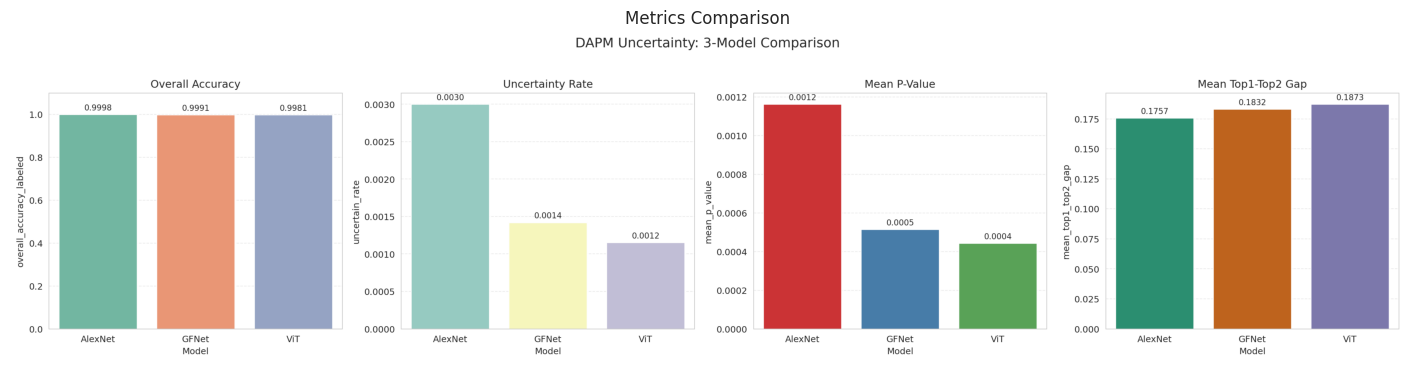

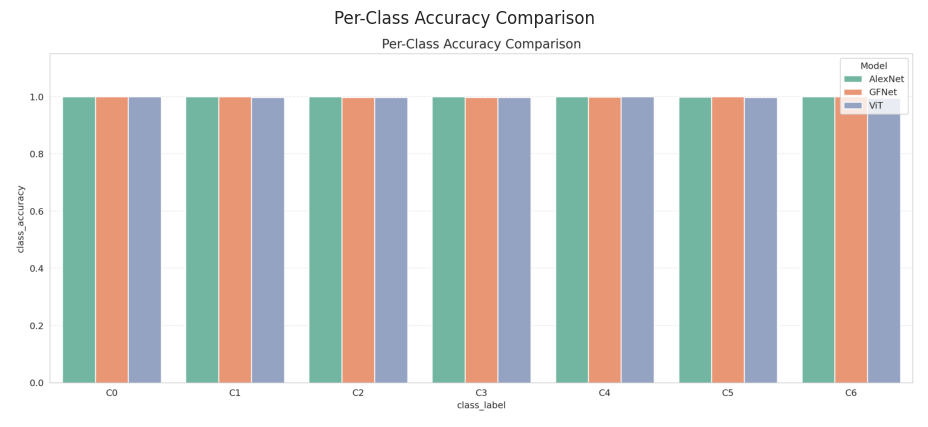

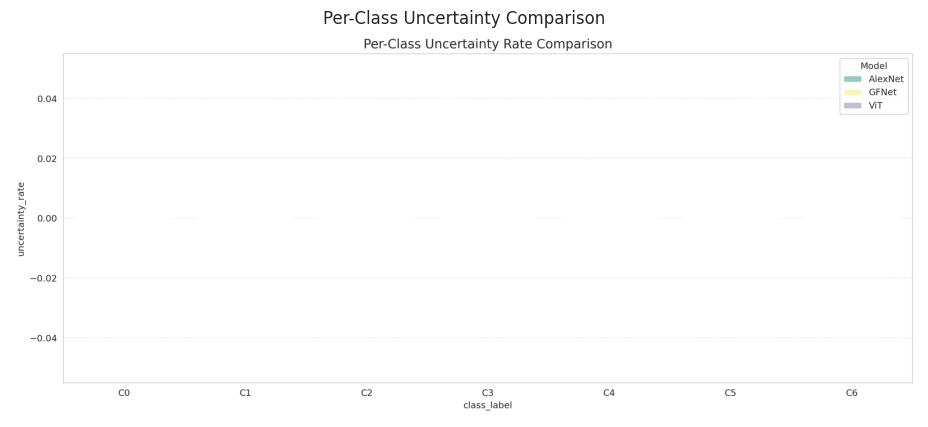

Saved workbook: /content/local_outputs/dapm_full/dapm_full_reports_all_models.xlsx
Saved summary CSV: /content/local_outputs/dapm_full/dapm_full_summary_metrics.csv
Saved per-class CSV: /content/local_outputs/dapm_full/dapm_full_per_class_metrics.csv
Saved run config: /content/local_outputs/dapm_full/dapm_full_run_config.json


In [15]:
# =============================================================
# Rebuild summary + Save everything
# =============================================================

# Rebuild dataframes from already-computed results
summary_df = pd.DataFrame(summary_rows)

per_class_all_df = pd.concat([
    o['per_class_df'].assign(model_name=o['model_name'], model_key=o['model_key'])
    for o in all_outputs
], ignore_index=True)

# Build comparison plots with error handling
def build_comparison_buffers(sdf, all_out):
    bufs = {}
    metrics = [
        ('overall_accuracy_labeled', 'Overall Accuracy', 'Set2', (0, 1.1)),
        ('uncertain_rate', 'Uncertainty Rate', 'Set3', None),
        ('mean_p_value', 'Mean P-Value', 'Set1', None),
        ('mean_top1_top2_gap', 'Mean Top1-Top2 Gap', 'Dark2', None),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for ax, (col, title, pal, ylim) in zip(axes, metrics):
        sns.barplot(data=sdf, x='model_name', y=col, ax=ax, palette=pal)
        ax.set_title(title, fontsize=12); ax.set_xlabel('Model')
        ax.grid(axis='y', ls='--', alpha=0.4); add_bar_labels(ax, fmt='{:.4f}')
        if ylim: ax.set_ylim(*ylim)
    fig.suptitle('DAPM Uncertainty: 3-Model Comparison', fontsize=15, y=1.03)
    fig.tight_layout()
    bufs['Metrics Comparison'] = fig_to_buf(fig)

    all_pc = pd.concat([
        o['per_class_df'].assign(model_name=o['model_name']) for o in all_out
    ], ignore_index=True)
    all_pc['class_label'] = all_pc['class_id'].apply(lambda c: f'C{c}')

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=all_pc, x='class_label', y='class_accuracy',
                hue='model_name', ax=ax, palette='Set2')
    ax.set_title('Per-Class Accuracy Comparison', fontsize=14)
    ax.set_ylim(0, 1.15); ax.legend(title='Model')
    ax.grid(axis='y', ls='--', alpha=0.4); fig.tight_layout()
    bufs['Per-Class Accuracy Comparison'] = fig_to_buf(fig)

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=all_pc, x='class_label', y='uncertainty_rate',
                hue='model_name', ax=ax, palette='Set3')
    ax.set_title('Per-Class Uncertainty Rate Comparison', fontsize=14)
    ax.legend(title='Model'); ax.grid(axis='y', ls='--', alpha=0.4)
    fig.tight_layout()
    bufs['Per-Class Uncertainty Comparison'] = fig_to_buf(fig)
    return bufs

try:
    comparison_bufs = build_comparison_buffers(summary_df, all_outputs)
    print('Comparison plots built successfully')
except Exception as e:
    print(f'Comparison plots failed: {e}')
    comparison_bufs = {}

print(summary_df.to_string(index=False))

# Display inline
for name, buf in comparison_bufs.items():
    buf.seek(0)
    img = plt.imread(buf)
    fig, ax = plt.subplots(figsize=(18, 5))
    ax.imshow(img); ax.axis('off'); ax.set_title(name)
    plt.show()

# Save CSVs + JSON
summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
per_class_all_df.to_csv(PER_CLASS_CSV_PATH, index=False)

run_config = {
    'seed': SEED, 'project_root': str(PROJECT_ROOT),
    'model_dir': str(MODEL_DIR), 'dapm_dir': str(DAPM_DIR),
    'output_dir': str(OUTPUT_DIR), 'data_file': str(DATA_FILE),
    'label_file': str(LABEL_FILE), 'h': H, 'w': W, 'b': B,
    'patch_size': PATCH_SIZE, 'n_samples': N_SAMPLES,
    'p_threshold': P_THRESH, 'batch_size': BATCH_SIZE,
    'scene_chunk_size': SCENE_CHUNK_SIZE,
    'diffusion_steps': 'full_T (per model config)',
    'models': MODEL_KEYS,
    'timestamp_utc': pd.Timestamp.utcnow().isoformat(),
}
with open(RUN_CONFIG_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(run_config, f, indent=2)

# Rich Excel workbook
try:
    used_sheets = set()
    with pd.ExcelWriter(EXCEL_PATH, engine='xlsxwriter') as writer:
        workbook = writer.book
        s = make_sheet_name('Summary_Compact', used_sheets)
        summary_df.to_excel(writer, sheet_name=s, index=False)
        s = make_sheet_name('Run_Config', used_sheets)
        pd.DataFrame(list(run_config.items()),
                     columns=['key', 'value']).to_excel(writer, sheet_name=s, index=False)
        s = make_sheet_name('PerClass_All', used_sheets)
        per_class_all_df.to_excel(writer, sheet_name=s, index=False)
        for output in all_outputs:
            s = make_sheet_name(f'DAPM_{output["model_name"]}', used_sheets)
            write_model_sheet(writer, workbook, output, s)
        if comparison_bufs:
            s = make_sheet_name('Compare_DAPM', used_sheets)
            write_comparison_sheet(writer, workbook, s, summary_df, comparison_bufs)
    print('Saved workbook:', EXCEL_PATH)
except Exception as e:
    print(f'Excel write error: {type(e).__name__}: {e}')
    import traceback
    traceback.print_exc()

print('Saved summary CSV:', SUMMARY_CSV_PATH)
print('Saved per-class CSV:', PER_CLASS_CSV_PATH)
print('Saved run config:', RUN_CONFIG_JSON_PATH)



In [16]:
# =============================================================
# Validation + Copy to Drive
# =============================================================
from openpyxl import load_workbook as _load_wb

assert EXCEL_PATH.exists(), f'Workbook missing: {EXCEL_PATH}'
assert SUMMARY_CSV_PATH.exists()
assert PER_CLASS_CSV_PATH.exists()
assert RUN_CONFIG_JSON_PATH.exists()
assert summary_df.shape[0] == 3

wb = _load_wb(EXCEL_PATH, read_only=True)
existing = set(wb.sheetnames)
print(f'Excel sheets: {wb.sheetnames}')
wb.close()

for out in all_outputs:
    pc_total = out['pixel_counts_df']['pixel_count'].sum()
    assert int(pc_total) == H * W, f'Pixel count mismatch for {out["model_key"]}'

print(f'Validation passed. Sheets: {len(existing)}, Summary rows: {len(summary_df)}')

# Copy to Drive
DRIVE_OUTPUT_DIR = LOCAL_DAPM_DIR_ORIG.parent.parent / 'results' / 'dapm_full'
DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for f in OUTPUT_DIR.iterdir():
    if f.is_file():
        shutil.copy2(str(f), str(DRIVE_OUTPUT_DIR / f.name))
        print(f'Copied {f.name} → Drive')

DRIVE_CHUNK = DRIVE_OUTPUT_DIR / 'chunk_outputs'
DRIVE_CHUNK.mkdir(parents=True, exist_ok=True)
for f in CHUNK_DIR.iterdir():
    if f.is_file():
        shutil.copy2(str(f), str(DRIVE_CHUNK / f.name))

DRIVE_MAPS = DRIVE_OUTPUT_DIR / 'maps'
DRIVE_MAPS.mkdir(parents=True, exist_ok=True)
for f in MAP_DIR.iterdir():
    if f.is_file():
        shutil.copy2(str(f), str(DRIVE_MAPS / f.name))

print(f'\nAll saved to Drive: {DRIVE_OUTPUT_DIR}')
print(f'  chunks: {sum(1 for _ in DRIVE_CHUNK.iterdir())} files')
print(f'  maps: {sum(1 for _ in DRIVE_MAPS.iterdir())} files')



Excel sheets: ['Summary_Compact', 'Run_Config', 'PerClass_All', 'DAPM_AlexNet', 'DAPM_GFNet', 'DAPM_ViT', 'Compare_DAPM']
Validation passed. Sheets: 7, Summary rows: 3
Copied dapm_full_summary_metrics.csv → Drive
Copied dapm_full_run_config.json → Drive
Copied dapm_full_reports_all_models.xlsx → Drive
Copied dapm_full_per_class_metrics.csv → Drive

All saved to Drive: /content/drive/My Drive/m_p/uncertainty_results/dapm_full
  chunks: 306 files
  maps: 39 files
